# Introduction to the General Linear Model


> Adapted from [DartBrains](https://dartbrains.org/) by Luke Chang (© Luke Chang, supported by NSF CAREER Award 1848370), used under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). **Changes made:** trimmed to the exercise sections, setup code reduced to the cells the exercises depend on, display-only calls removed. Exercise solutions are my own work. This notebook is therefore also distributed under CC BY-SA 4.0. No endorsement by the original author is implied.


In [ ]:
%matplotlib inline
pass
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltools.stats import regress
from nltools.external import glover_hrf

In [ ]:
n_tr = 200
n_trial = 5
face = np.zeros(n_tr)
face[np.arange(10, n_tr, int(n_tr / n_trial))] = 1

def plot_timeseries(data, labels=None, linewidth=3):
    """Plot a timeseries

    Args:
        data: (np.ndarray) signal varying over time, where each column is a different signal.
        labels: (list) labels which need to correspond to the number of columns.
        linewidth: (int) thickness of line
    """
    plt.figure(figsize=(20, 5))
    plt.plot(data, linewidth=linewidth)
    plt.ylabel('Intensity', fontsize=18)
    plt.xlabel('Time', fontsize=18)
    plt.tight_layout()
    if labels is not None:
        if len(labels) != data.shape[1]:
            raise ValueError('Need to have the same number of labels as columns in data.')
        plt.legend(labels, fontsize=18)
plot_timeseries(face)

## Exercises

For our homework exercises, let's use the simulation to answer questions we might have about experimental design.

### Exercise 1. What happens when we vary the signal amplitude?

Some signals will be very strong and others weaker. How does the model fit change when the signal amplitudes are stronger and weaker?

In this exercise, make a plot showing how the $r^2$ changes over 3 different levels of signal intensity.

Text(0.5, 0, 'total signal amplitude')

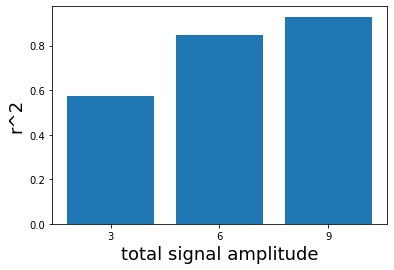

In [ ]:
# parameters
n_tr = 200
n_trial = 5
face_intensity = [2, 4, 6]
object_intensity = [1, 2, 3]
sigma = 0.15

# glm estimator function
def ols_estimator(X, Y):
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), Y)

# r^2 function
def r_square(Y, predicted_y):
    SS_total = np.sum((Y - np.mean(Y))**2) # compute the total sum of squares
    SS_residual = np.sum((Y - predicted_y)**2) # compute the residual sum of squares
    return 1-(SS_residual/SS_total)

r2 = []
ampTot = []
for AMP in range(len(face_intensity)):

    # generate signals
    face = np.zeros(n_tr)
    face[np.arange(10, n_tr, int(n_tr/n_trial))] = face_intensity[AMP]
    obj = np.zeros(n_tr)
    obj[np.arange(20, n_tr, int(n_tr/n_trial))] = object_intensity[AMP]
    voxel = np.vstack([face,obj]).T

    # convolve with hrf kernel
    tr = 2
    hrf = glover_hrf(tr, oversampling=1)
    face_conv = np.convolve(face, hrf, mode='same')
    obj_conv = np.convolve(obj, hrf, mode='same')
    voxel_conv = np.vstack([face_conv, obj_conv]).T

    # add noise
    epsilon = sigma*np.random.randn(n_tr, 2)
    voxel_conv_noise = voxel_conv + epsilon

    # sum signals to get voxel time series (Y)
    Y = voxel_conv_noise.sum(axis=1)

    # generate design matrix
    face = np.zeros(n_tr)
    face[np.arange(10, n_tr, int(n_tr/n_trial))] = 1
    obj = np.zeros(n_tr)
    obj[np.arange(20, n_tr, int(n_tr/n_trial))] = 1
    intercept = np.ones(n_tr)
    X = np.vstack([intercept, np.convolve(face, hrf, mode='same'), np.convolve(obj, hrf, mode='same')]).T

    # estimate GLM
    beta = ols_estimator(X, Y)

    # get predicted Y-values
    predicted_y = np.dot(X, beta) # get predicted Y values

    # get r^2
    r2.append(r_square(Y, predicted_y))

    # get total signal amplitude
    ampTot.append(face_intensity[AMP] + object_intensity[AMP])

# plot
plt.bar([str(ampTot[0]),str(ampTot[1]),str(ampTot[2])], r2)
plt.ylabel('r^2', fontsize=18)
plt.xlabel('total signal amplitude', fontsize=18)

### Exercise 2. What happens when we vary the noise?

How does the amount of noise in the data impact our model fits?  

In this exercise, make a plot showing the $r^2$ for 3 different levels of simulated noise.

Text(0.5, 0, 'noise sigma')

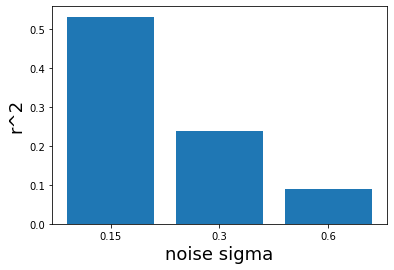

In [ ]:
# parameters
n_tr = 200
n_trial = 5
face_intensity = 2
object_intensity = 1
sigma = [0.15, 0.3, 0.6]


# glm estimator function
def ols_estimator(X, Y):
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), Y)

# r^2 function
def r_square(Y, predicted_y):
    SS_total = np.sum((Y - np.mean(Y))**2) # compute the total sum of squares
    SS_residual = np.sum((Y - predicted_y)**2) # compute the residual sum of squares
    return 1-(SS_residual/SS_total)

# f, ax = plt.subplots(nrows=3,sharex=True)

r2 = []
for NOISE in range(len(sigma)):

    # generate signals
    face = np.zeros(n_tr)
    face[np.arange(10, n_tr, int(n_tr/n_trial))] = face_intensity
    obj = np.zeros(n_tr)
    obj[np.arange(20, n_tr, int(n_tr/n_trial))] = object_intensity
    voxel = np.vstack([face,obj]).T

    # convolve with hrf kernel
    tr = 2
    hrf = glover_hrf(tr, oversampling=1)
    face_conv = np.convolve(face, hrf, mode='same')
    obj_conv = np.convolve(obj, hrf, mode='same')
    voxel_conv = np.vstack([face_conv, obj_conv]).T

    # add noise
    epsilon = sigma[NOISE] * np.random.randn(n_tr, 2)
    voxel_conv_noise = voxel_conv + epsilon

    # sum signals to get voxel time series (Y)
    Y = voxel_conv_noise.sum(axis=1)

    # generate design matrix
    face = np.zeros(n_tr)
    face[np.arange(10, n_tr, int(n_tr/n_trial))] = 1
    obj = np.zeros(n_tr)
    obj[np.arange(20, n_tr, int(n_tr/n_trial))] = 1
    intercept = np.ones(n_tr)
    X = np.vstack([intercept, np.convolve(face, hrf, mode='same'), np.convolve(obj, hrf, mode='same')]).T

    # estimate GLM
    beta = ols_estimator(X, Y)

    # get predicted Y-values
    predicted_y = np.dot(X, beta) # get predicted Y values

    # get r^2
    r2.append(r_square(Y, predicted_y))

# plot
plt.bar([str(sigma[0]),str(sigma[1]),str(sigma[2])], r2)
plt.ylabel('r^2', fontsize=18)
plt.xlabel('noise sigma', fontsize=18)

### Exercise 3. How many trials do we need?

A common question in experimental design is determining the optimal number of trials.

In this exercise, try evaluating how 3 different numbers of trials might impact the contrast efficiency.

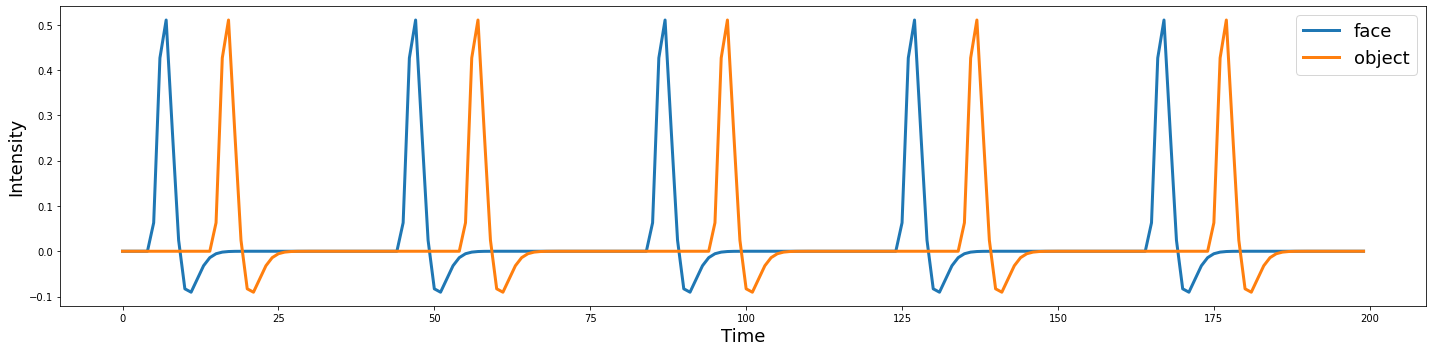

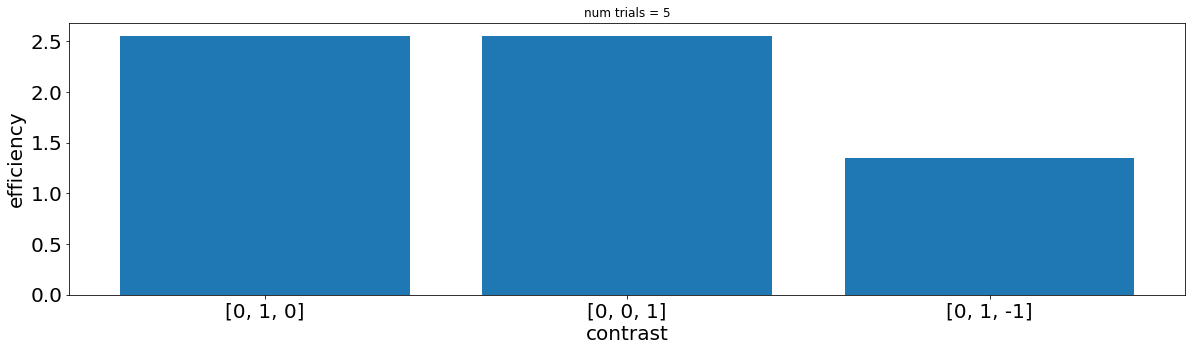

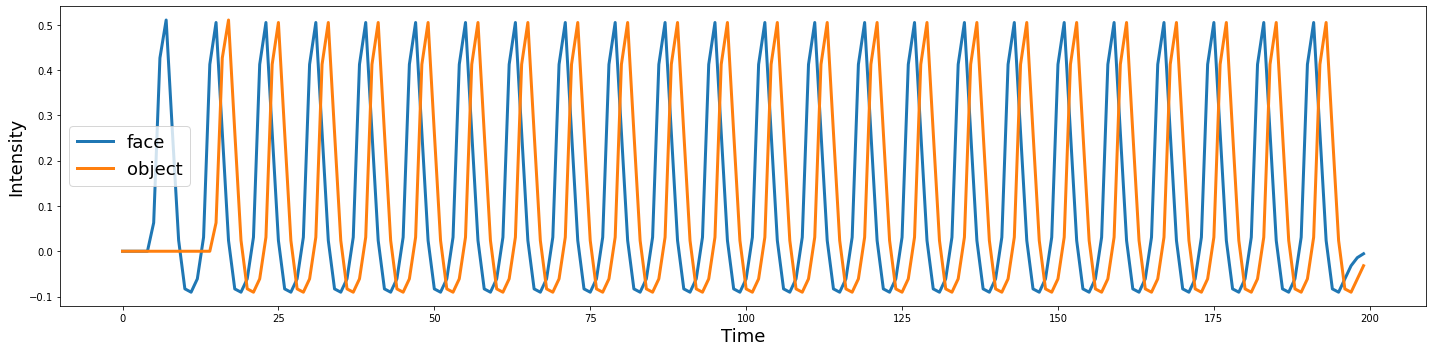

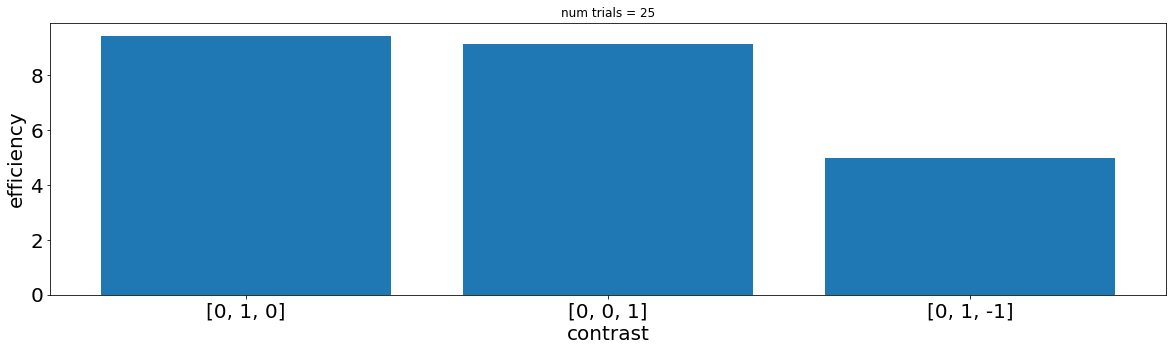

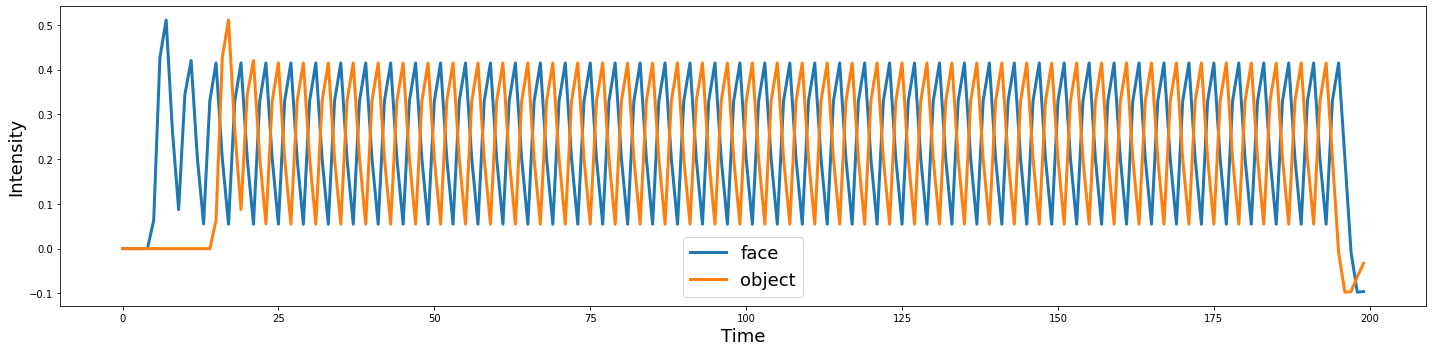

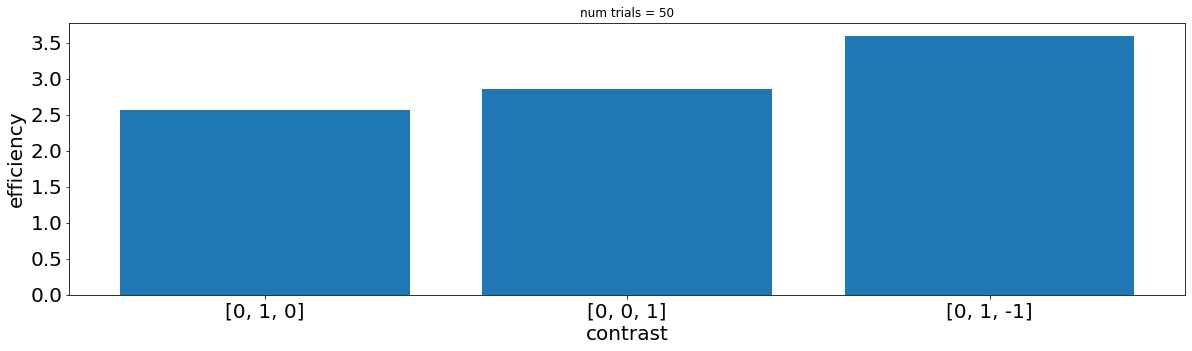

In [ ]:
# parameters
n_tr = 200
n_trial = [5, 25, 50]
face_intensity = 2
object_intensity = 1
sigma = 0.15

# glm estimator function
def ols_estimator(X, Y):
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), Y)

# contrast efficiency function
def contrast_efficiency(X, contrast):
    c = np.array(contrast)
    return 1/(np.dot(np.dot(c, np.linalg.pinv(np.dot(X.T, X))), c.T))

# define contrasts
c1 = [0, 1, 0]
c2 = [0, 0, 1]
c3 = [0, 1, -1]

conEffic = []
for TNUM in range(len(n_trial)):

    # generate design matrix
    face = np.zeros(n_tr)
    face[np.arange(10, n_tr, int(n_tr/n_trial[TNUM]))] = 1
    obj = np.zeros(n_tr)
    obj[np.arange(20, n_tr, int(n_tr/n_trial[TNUM]))] = 1
    intercept = np.ones(n_tr)
    X = np.vstack([intercept, np.convolve(face, hrf, mode='same'), np.convolve(obj, hrf, mode='same')]).T

    # get contrast efficiency
    conEffic.append([contrast_efficiency(X, x) for x in [c1, c2, c3]])

    # plot design matrix for face and object predictors
    plot_timeseries(X[:,1:],['face','object'])

    # plot contrast efficieny
    plt.figure(figsize=(20,5))
    plt.bar([str(c1),str(c2),str(c3)], conEffic[TNUM])
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('contrast',fontsize=20)
    plt.ylabel('efficiency',fontsize=20)
    plt.title(f'num trials = {n_trial[TNUM]}')


### Exercise 4. What is the impact of the stimulus duration?

What if one condition simply results in processes that systematically take longer than the other condition?

In this exercise, let's try to answer this question by creating a simulation where the signal intensity between the two condition is identical, but one simply has a longer duration (i.e., the duration has more TRs than the other condition).

Make a plot showing what happens to the $\beta$ estimates.

betas when face_dur=1: [-0.00388664  1.06107851  1.12874305]
betas when face_dur=4: [0.05837759 1.99322947 0.94737249]
betas when face_dur=10: [0.24283972 1.28697474 0.57359734]


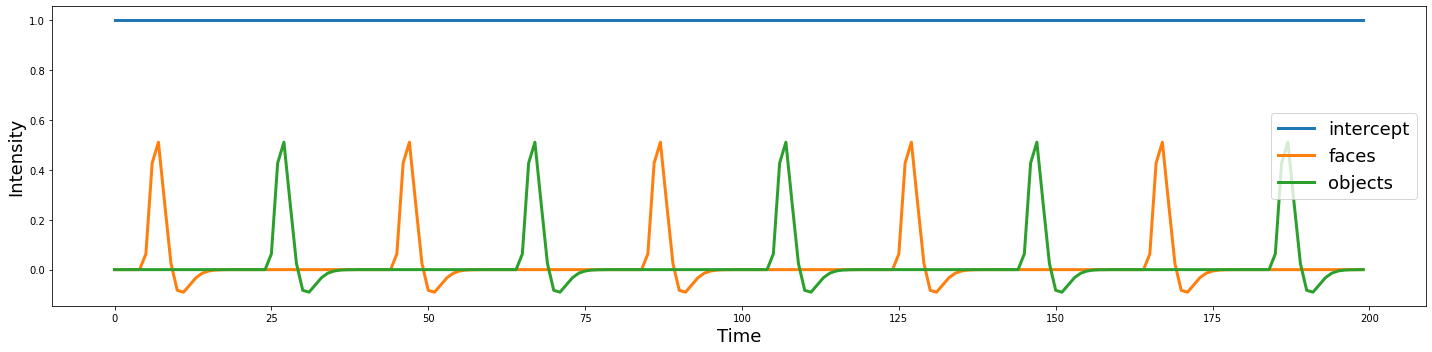

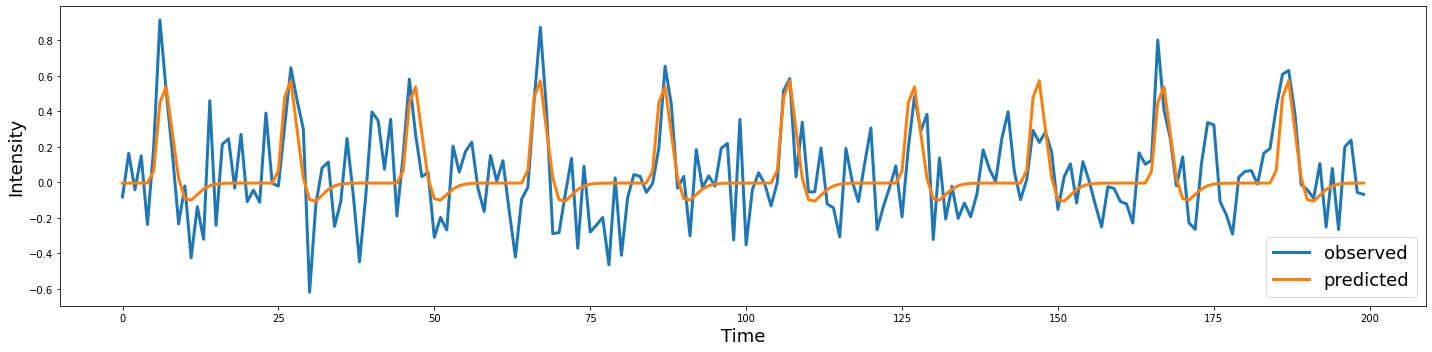

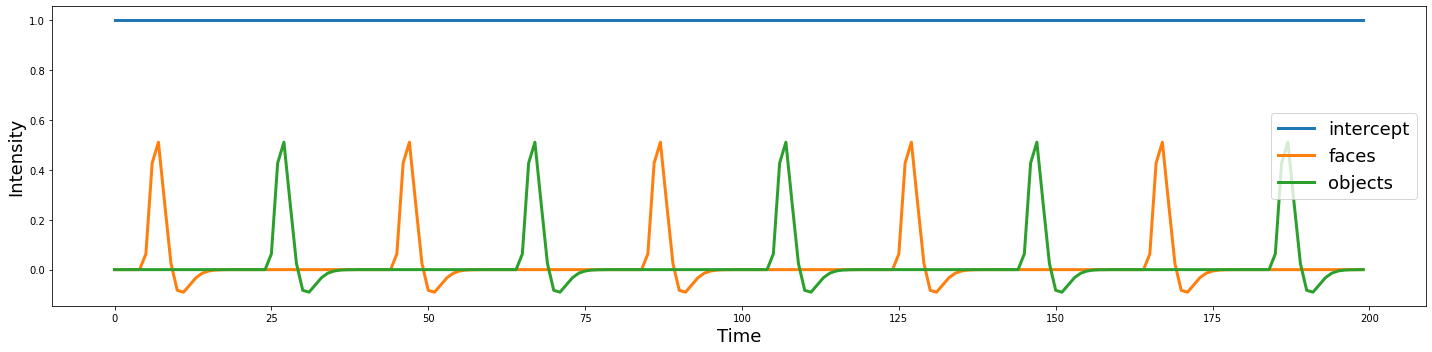

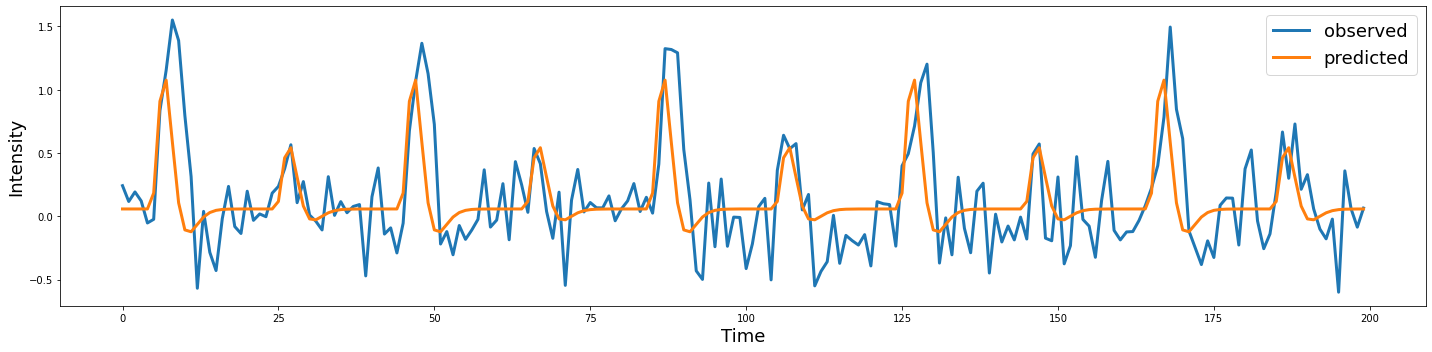

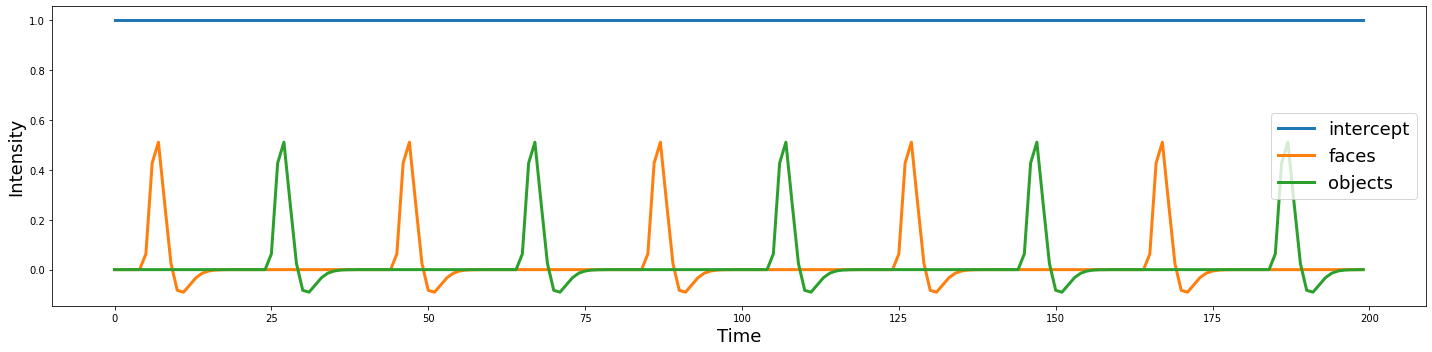

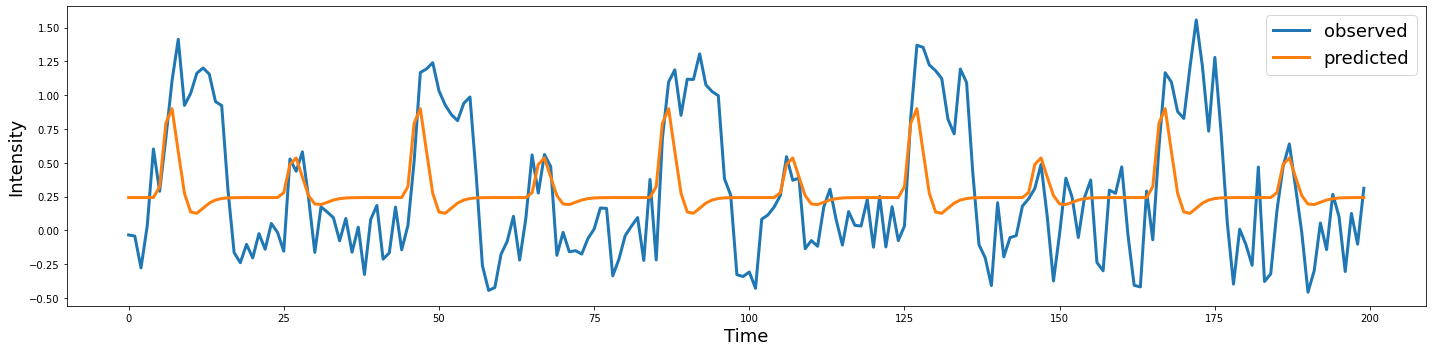

In [ ]:
# parameters
n_tr = 200
n_trial = 5
face_intensity = 1
face_dur = [1, 4, 10]
object_intensity = 1
object_dur = 1
sigma = 0.15

# glm estimator function
def ols_estimator(X, Y):
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), Y)

for DUR in range(len(face_dur)):

    # generate signals
    face = np.zeros(n_tr)
    face_onsets = np.arange(10, n_tr, int(n_tr/n_trial))
    face_OG = np.zeros(n_tr)
    face_OG[face_onsets] = 1
    for STIM in face_onsets:
        for TR in range(face_dur[DUR]):
            face[face_onsets+TR] = face_intensity
    obj = np.zeros(n_tr)
    obj[np.arange(30, n_tr, int(n_tr/n_trial))] = object_intensity
    voxel = np.vstack([face,obj]).T

    # convolve with hrf kernel
    tr = 2
    hrf = glover_hrf(tr, oversampling=1)
    face_conv = np.convolve(face, hrf, mode='same')
    obj_conv = np.convolve(obj, hrf, mode='same')
    voxel_conv = np.vstack([face_conv, obj_conv]).T

    # add noise
    epsilon = sigma*np.random.randn(n_tr, 2)
    voxel_conv_noise = voxel_conv + epsilon

    # sum signals to get voxel time series (Y)
    Y = voxel_conv_noise.sum(axis=1)

    # generate design matrix
    face = np.zeros(n_tr)
    for STIM in face_onsets:
        for TR in range(face_dur[DUR]):
            face[face_onsets+TR] = 1
    intercept = np.ones(n_tr)
    X = np.vstack([intercept, np.convolve(face_OG, hrf, mode='same'), np.convolve(obj, hrf, mode='same')]).T

    # plot design matrix (without intercept)
    plot_timeseries(X,['intercept','faces','objects'])

    # estimate GLM and print betas
    beta = ols_estimator(X, Y)
    print(f'betas when face_dur={face_dur[DUR]}: {beta}')

    # get predicted values
    predicted_y = np.dot(X,beta)

    # plot observed over predicted values
    plot_timeseries(pd.DataFrame([Y,predicted_y]).T,['observed','predicted'])